In [1]:
#!/usr/bin/env python
# coding: utf-8

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import h5py
import os
import scipy.io
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import random

# Set seeds for reproducibility
random.seed(42)  # For Python's built-in random module
np.random.seed(42)  # For NumPy
tf.random.set_seed(42)  # For TensorFlow

# Optionally, set TensorFlow to deterministic mode for even more reproducibility
os.environ['TF_DETERMINISTIC_OPS'] = '1'

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Function to generate file names based on the input format

In [3]:
# Function to generate file names based on the input format
name_format = "FCNN_Bz_UQtest"
print("Note: use results16.mat which has 10000 datasets; B only has positive Z values")
file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results16.mat which has 10000 datasets; B only has positive Z values


In [4]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [5]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [6]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [7]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [8]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [9]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

File paths for training and testing data

In [10]:
# Example usage
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)

# Data is now loaded and processed.
print("Data reading completed.")

Processing results16.mat as a .mat file...
Data reading completed.


In [11]:
# Filter out low-variance columns
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)
start_index, end_index = 0, I_data.shape[1] - 1

for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

I_data_filtered = I_data[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

def resample_and_smooth_data(normalized_data, new_length=1200):
    resampled_data = []
    
    for row in normalized_data:
        original_length = len(row)
        # Define the original x values (relative position in the original data)
        x_original = np.linspace(0, 1, num=original_length)
        
        # Define the new x values (for the desired length)
        x_new = np.linspace(0, 1, num=new_length)
        
        # Use cubic interpolation to resample and smooth
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_row = f(x_new)
        
        resampled_data.append(resampled_row)
    
    return np.array(resampled_data)

# Resample and smooth the normalized data to ensure each element has a length of 1200
normalized_I_resampled = resample_and_smooth_data(normalized_I, new_length=1200)

# Flatten the I_data to use as input for the neural network
I_data_flat = normalized_I_resampled.reshape(normalized_I_resampled.shape[0], -1)

# Stack only non-zero B and E components to create the output (target) data
target_data = np.column_stack((B_MAG_data[:, 2], EDC_MAG_data))

# Split the data into training and testing sets
I_train, I_test, target_train, target_test = train_test_split(I_data_flat, target_data, test_size=0.2, random_state=42)

# Only the B3 component is used for training now
B_train = target_train[:, :1]
E_train = target_train[:, 1:]
B_test = target_test[:, :1]
E_test = target_test[:, 1:]

# Scaling the B3 and E components
scaler_B3 = MinMaxScaler()
B_train_scaled = scaler_B3.fit_transform(B_train)
B_test_scaled = scaler_B3.transform(B_test)

scaler_E1 = MinMaxScaler()
scaler_E2 = MinMaxScaler()
scaler_E3 = MinMaxScaler()

E_train_scaled = np.column_stack((
    scaler_E1.fit_transform(E_train[:, 0].reshape(-1, 1)),
    scaler_E2.fit_transform(E_train[:, 1].reshape(-1, 1)),
    scaler_E3.fit_transform(E_train[:, 2].reshape(-1, 1))
))
E_test_scaled = np.column_stack((
    scaler_E1.transform(E_test[:, 0].reshape(-1, 1)),
    scaler_E2.transform(E_test[:, 1].reshape(-1, 1)),
    scaler_E3.transform(E_test[:, 2].reshape(-1, 1))
))

target_train_scaled = np.column_stack((B_train_scaled, E_train_scaled))
target_test_scaled = np.column_stack((B_test_scaled, E_test_scaled))


Data is now loaded and processed.

In [12]:
print("Data organized.", flush=True)

Data organized.


In [13]:
from tensorflow.keras.callbacks import Callback
class LossMonitor(Callback):
    def on_batch_end(self, batch, logs=None):
        if batch % 100 == 0:
            print(f"Batch {batch}: loss = {logs['loss']}")

In [14]:
model = Sequential([
    # Reduced dropout and regularization, introduced Swish activation
    Dense(512, kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),  # Reduced dropout further
    
    Dense(256, kernel_regularizer=l2(0.0003)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),
    
    Dense(128, kernel_regularizer=l2(0.0001)),  # Reduced regularization in the later layers
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.1),  # Minimal dropout for smaller layer
    
    Dense(64, kernel_regularizer=l2(0.0001), activation='swish'),
    Dropout(0.1),  # Further reduced dropout
    
    Dense(32, activation='swish'), # No regularization, small dropout for the final layer
    
    Dense(16, activation='swish'),

    Dense(4)  # Output layer
])

In [15]:
def custom_loss(y_true, y_pred):
    B_true, E_true = y_true[:, :1], y_true[:, 1:]
    B_pred, E_pred = y_pred[:, :1], y_pred[:, 1:]
    loss_B = tf.reduce_mean(tf.square(B_true - B_pred), axis=0)
    loss_E = tf.reduce_mean(tf.square(E_true - E_pred), axis=0)
    weight_B = tf.constant([1.0])
    weight_E = tf.constant([1.0, 1.0, 1.0])
    total_loss = tf.reduce_sum(weight_B * loss_B) + tf.reduce_sum(weight_E * loss_E)
    return total_loss

In [16]:
# model.compile(optimizer=Adam(learning_rate=0.0005), loss=custom_loss, metrics=['mae'])

model.compile(optimizer=RMSprop(learning_rate=0.0001), loss=custom_loss, metrics=['mse'])


In [17]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

In [18]:
history = model.fit(
    I_train, 
    target_train_scaled, 
    epochs=400, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[lr_scheduler, early_stopping, LossMonitor()]
)

Epoch 1/400
Batch 0: loss = 2.005833864212036
200/200 [==============================] - 3s 6ms/step - loss: 0.9473 - mse: 0.1156 - val_loss: 0.6814 - val_mse: 0.0499 - lr: 1.0000e-04
Epoch 2/400
Batch 0: loss = 0.6792704463005066
200/200 [==============================] - 1s 5ms/step - loss: 0.6809 - mse: 0.0509 - val_loss: 0.5733 - val_mse: 0.0254 - lr: 1.0000e-04
Epoch 3/400
Batch 0: loss = 0.657855212688446
200/200 [==============================] - 1s 5ms/step - loss: 0.6154 - mse: 0.0377 - val_loss: 0.5227 - val_mse: 0.0166 - lr: 1.0000e-04
Epoch 4/400
Batch 0: loss = 0.5731140971183777
200/200 [==============================] - 1s 5ms/step - loss: 0.5657 - mse: 0.0296 - val_loss: 0.4890 - val_mse: 0.0128 - lr: 1.0000e-04
Epoch 5/400
Batch 0: loss = 0.5294557809829712
200/200 [==============================] - 1s 5ms/step - loss: 0.5259 - mse: 0.0247 - val_loss: 0.4613 - val_mse: 0.0112 - lr: 1.0000e-04
Epoch 6/400
Batch 0: loss = 0.49218499660491943
200/200 [====================

In [19]:
model_save_path = os.path.join("/home/botingl/machine learning", generate_filename("model", "h5"))
model.save(model_save_path)
print("Model saved successfully.")

Model saved successfully.


In [20]:
model = tf.keras.models.load_model(model_save_path, custom_objects={'custom_loss': custom_loss})
print("Model loaded successfully.")

Model loaded successfully.


Whole model evaluation (NMSE, rMAE, R²)

In [21]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

Component-wise evaluation (MSE, MAE, R²)

In [22]:
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

Evaluation metrics for the training data

In [23]:
print("Start to evaluate the training set.", flush=True)
# np.random.seed(42)
size = len(I_train) if len(I_train) < 1000 else 1000
train_subset_indices = np.random.choice(len(I_train), size=size, replace=False)
train_input_data_subset = I_train[train_subset_indices]
train_target_data_subset = target_train_scaled[train_subset_indices]

Start to evaluate the training set.


In [24]:
import time

# Measure the time taken for the entire prediction process
start_time = time.time()

# Make predictions on the training data
predictions_train = model.predict(train_input_data_subset)

# Measure the end time
end_time = time.time()

# Calculate and print the time taken
time_taken = end_time - start_time
print(f"Time taken for prediction on the entire training set: {time_taken:.6f} seconds")

num_input = len(train_input_data_subset)
time_each = time_taken/num_input
print(f"Time taken for prediction on each training set: {time_each:.6f} seconds")


32/32 [==============================] - 0s 2ms/step
Time taken for prediction on the entire training set: 0.260593 seconds
Time taken for prediction on each training set: 0.000261 seconds


In [25]:
import numpy as np

# Define Monte Carlo Sampling Function
def monte_carlo_predictions(model, x_input, num_samples=100):
    """
    Perform Monte Carlo Dropout Sampling on a Keras model.
    This assumes the model has dropout layers.
    """
    preds = []
    for _ in range(num_samples):
        # Manually enable training mode for dropout
        preds.append(model(x_input, training=True).numpy())  # Force training=True for dropout
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

# Generate Predictions with Uncertainty
mean_train, std_dev_train = monte_carlo_predictions(model, train_input_data_subset, num_samples=100)
lower_bound_train = mean_train - 1.96 * std_dev_train  # 95% confidence interval
upper_bound_train = mean_train + 1.96 * std_dev_train

print("Mean Predictions:", mean_train)
print("Standard Deviations:", std_dev_train)


Mean Predictions: [[0.37989444 0.03189539 0.22910556 0.00511076]
 [0.6069105  0.96038747 0.42740348 0.19704194]
 [0.6255939  0.20638001 0.22497472 0.31395897]
 ...
 [0.5891265  0.674658   0.77706873 0.90968734]
 [0.87623304 0.61810803 0.44789088 0.559096  ]
 [0.7778574  0.7138048  0.3044054  0.03203679]]
Standard Deviations: [[0.08789632 0.04271505 0.05080616 0.0606929 ]
 [0.04486779 0.03875716 0.05094684 0.03599919]
 [0.05357226 0.04609504 0.03517877 0.03325206]
 ...
 [0.04699811 0.0577269  0.04191355 0.03823658]
 [0.0408849  0.04274505 0.03184774 0.03553612]
 [0.05929463 0.04495768 0.04989189 0.04556869]]


Scale back the predicted values to original range

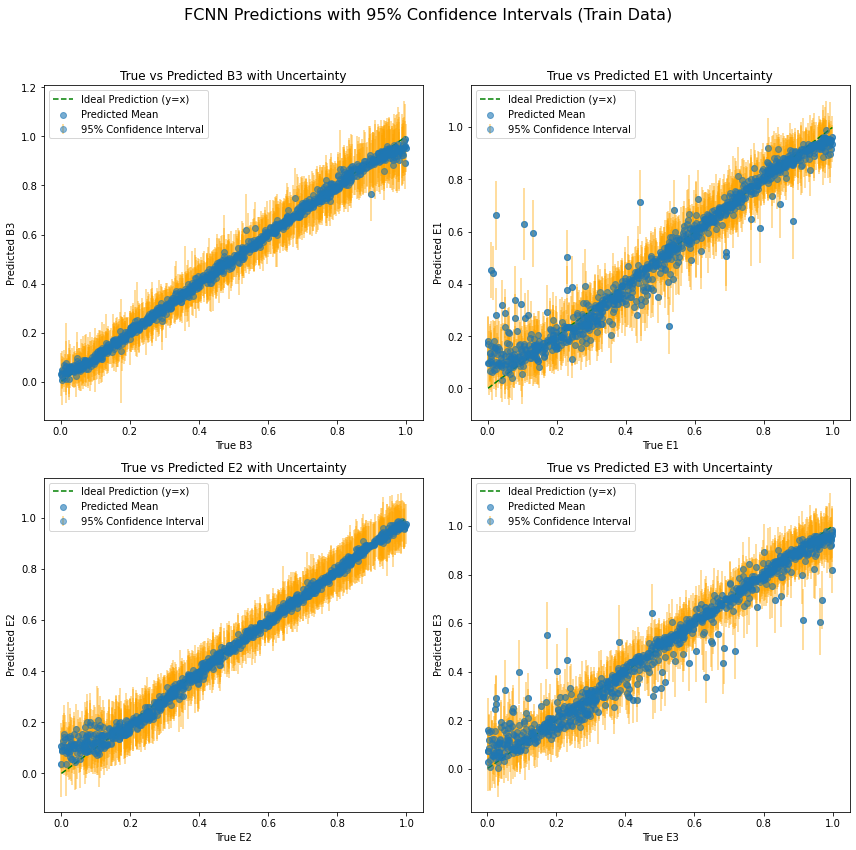

In [27]:
import matplotlib.pyplot as plt

# Define component names
components = ["B3", "E1", "E2", "E3"]

# Create subplots for each component
plt.figure(figsize=(12, 12))

for i in range(4):  # Iterate through the 4 components
    plt.subplot(2, 2, i + 1)
    
    # Scatter plot for true vs predicted
    plt.scatter(train_target_data_subset[:, i], mean_train[:, i], alpha=0.6, label="Predicted Mean")
    
    # Error bars for confidence intervals
    plt.errorbar(train_target_data_subset[:, i], mean_train[:, i], 
                 yerr=[mean_train[:, i] - lower_bound_train[:, i], upper_bound_train[:, i] - mean_train[:, i]], 
                 fmt='o', ecolor='orange', alpha=0.5, label="95% Confidence Interval")
    
    # Reference line (y = x)
    plt.plot([min(train_target_data_subset[:, i]), max(train_target_data_subset[:, i])], 
             [min(train_target_data_subset[:, i]), max(train_target_data_subset[:, i])], 
             'g--', label="Ideal Prediction (y=x)")
    
    # Axis labels and titles
    plt.xlabel(f"True {components[i]}")
    plt.ylabel(f"Predicted {components[i]}")
    plt.title(f"True vs Predicted {components[i]} with Uncertainty")
    plt.legend()

# Add overall title and adjust layout
plt.suptitle("FCNN Predictions with 95% Confidence Intervals (Train Data)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("Predictions with 95% Confidence Intervals (Train Data)", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()


In [29]:
# Generate Predictions with Uncertainty
mean_test, std_dev_test = monte_carlo_predictions(model, I_test, num_samples=100)
lower_bound_test = mean_test - 1.96 * std_dev_test  # 95% confidence interval
upper_bound_test = mean_test + 1.96 * std_dev_test

print("Mean Predictions:", mean_test)
print("Standard Deviations:", std_dev_test)


Mean Predictions: [[0.9222496  0.70897466 0.8797935  0.54412323]
 [0.93603647 0.8285079  0.86187476 0.38385513]
 [0.81796014 0.94193196 0.8150744  0.16394863]
 ...
 [0.1308771  0.26392874 0.96565163 0.2748054 ]
 [0.7354898  0.44769803 0.12715478 0.3091768 ]
 [0.6113728  0.06087625 0.24700184 0.05559532]]
Standard Deviations: [[0.05463089 0.0507591  0.04732891 0.04965029]
 [0.06391687 0.04331127 0.04808887 0.05518128]
 [0.05983325 0.04884871 0.05870547 0.05320342]
 ...
 [0.05899312 0.04954796 0.06171367 0.05294158]
 [0.04612886 0.03193071 0.04150214 0.04350251]
 [0.0759339  0.05418668 0.04037613 0.05531623]]


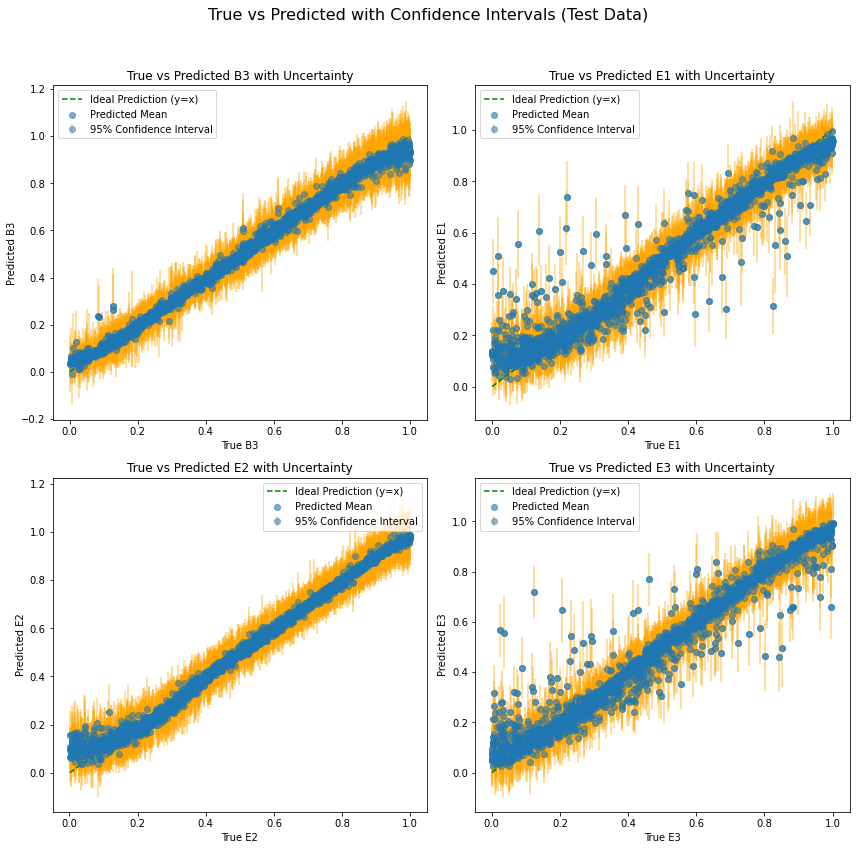

In [32]:
# Define component names
components = ["B3", "E1", "E2", "E3"]

# Create subplots for each component
plt.figure(figsize=(12, 12))

for i in range(4):  # Iterate through the 4 components
    plt.subplot(2, 2, i + 1)
    
    # Scatter plot for true vs predicted
    plt.scatter(target_test_scaled[:, i], mean_test[:, i], alpha=0.6, label="Predicted Mean")
    
    # Error bars for confidence intervals
    plt.errorbar(target_test_scaled[:, i], mean_test[:, i], 
                 yerr=[mean_test[:, i] - lower_bound_test[:, i], upper_bound_test[:, i] - mean_test[:, i]], 
                 fmt='o', ecolor='orange', alpha=0.5, label="95% Confidence Interval")
    
    # Reference line (y = x)
    plt.plot([min(target_test_scaled[:, i]), max(target_test_scaled[:, i])], 
             [min(target_test_scaled[:, i]), max(target_test_scaled[:, i])], 
             'g--', label="Ideal Prediction (y=x)")
    
    # Axis labels and titles
    plt.xlabel(f"True {components[i]}")
    plt.ylabel(f"Predicted {components[i]}")
    plt.title(f"True vs Predicted {components[i]} with Uncertainty")
    plt.legend()

# Add overall title and adjust layout
plt.suptitle("True vs Predicted with Confidence Intervals (Test Data)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("Predictions with 95% Confidence Intervals (Test Data)", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()
